<a href="https://colab.research.google.com/github/rpa0855-ai/delivery-time-prediction/blob/main/delivery_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delivery Time Prediction — Multiple Linear Regression











Classical MLR project: predict food delivery time (minutes) from order,





delivery-partner, and environmental features. Outlier/influence diagnostics





(Cook's Distance, DFFITS), multicollinearity handling (VIF + PCA), model





selection (backward elimination, AIC/BIC/Mallow's Cp/PRESS), and assumption





validation.











Data: real Swiggy delivery dataset, 45,593 rows, India.

### 1. Setup

In [ ]:
import pandas as pd





import numpy as np





import statsmodels.api as sm





from statsmodels.stats.outliers_influence import variance_inflation_factor





from statsmodels.stats.stattools import durbin_watson





from sklearn.decomposition import PCA





from sklearn.model_selection import train_test_split





from scipy import stats





import seaborn as sns





import matplotlib.pyplot as plt

In [ ]:
# Colab file upload — upload swiggy.csv





from google.colab import files





uploaded = files.upload()

Saving swiggy.csv to swiggy.csv


### 2. Load data

In [ ]:
df = pd.read_csv("swiggy.csv")





df.columns = df.columns.str.strip()





print(df.shape)





df.head()

(45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


### 3. Clean messy real-world columns

In [ ]:
# strip whitespace from every string column (dataset has trailing spaces everywhere)





str_cols = df.select_dtypes(include="object").columns





for c in str_cols:





    df[c] = df[c].astype(str).str.strip()











# weather column has "conditions Sunny" style -- strip the prefix BEFORE the





# NaN fix below, otherwise "conditions NaN" becomes the string "NaN" again





df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "", regex=False)











# 'NaN' is stored as a literal string, not an actual missing value -- fix that





df = df.replace("NaN", np.nan)











# target column is "(min) 24" style -- keep digits only





df["Time_taken(min)"] = df["Time_taken(min)"].str.extract(r"(\d+)").astype(float)











df[["Time_taken(min)", "Weatherconditions", "Road_traffic_density"]].head()

,Time_taken(min),Weatherconditions,Road_traffic_density
0,24.0,Sunny,High
1,33.0,Stormy,Jam
2,26.0,Sandstorms,Low
3,21.0,Sunny,Medium
4,30.0,Cloudy,High


### 4. Data quality cleaning — invalid coordinates, ratings, age

In [ ]:
before = len(df)











# India's valid lat/long bounds: 6°44'N-35°30'N, 68°7'E-97°25'E -- rows outside





# this (near-zero/corrupted GPS values) are bad data, not real deliveries





lat_ok = df["Restaurant_latitude"].between(6.73, 35.5) & df["Delivery_location_latitude"].between(6.73, 35.5)





lon_ok = df["Restaurant_longitude"].between(68.1, 97.4) & df["Delivery_location_longitude"].between(68.1, 97.4)





df = df[lat_ok & lon_ok]





print("dropped for invalid coordinates:", before - len(df))











# ratings are on a 1-5 scale -- a 6 is a data-entry error, not a real outlier.





# keep NaN here (handled later), only drop values that are explicitly invalid.





before2 = len(df)





df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")





df = df[~(df["Delivery_person_Ratings"] > 5)]





print("dropped for invalid rating (>5):", before2 - len(df))











# age 15 riders consistently show bad ratings, bad vehicle condition, and





# missing weather/traffic together -- looks like a bad-data cluster, not a





# genuine 15-year-old delivery workforce; drop rather than impute





before3 = len(df)





df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")





df = df[(df["Delivery_person_Age"] > 15) | (df["Delivery_person_Age"].isna())]





print("dropped for age==15 anomaly:", before3 - len(df))











print("rows remaining:", len(df))

dropped for invalid coordinates: 4071
dropped for invalid rating (>5): 24
dropped for age==15 anomaly: 25
rows remaining: 41473


### 5. Feature engineering — distance from lat/long

In [ ]:
def haversine(lat1, lon1, lat2, lon2):





    R = 6371  # km





    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])





    dlat = lat2 - lat1





    dlon = lon2 - lon1





    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2





    return 2 * R * np.arcsin(np.sqrt(a))











df["Distance_km"] = haversine(df["Restaurant_latitude"], df["Restaurant_longitude"],





                                df["Delivery_location_latitude"], df["Delivery_location_longitude"])





# with proper India-bounds coordinate cleaning already done, distance should





# now be realistic (roughly 1-25km) without needing an arbitrary cutoff





df["Distance_km"].describe()

,Distance_km
count,41473.000000
mean,9.719256
std,5.602950
min,1.465067
25%,4.657655
50%,9.193021
75%,13.680920
max,20.969489


### 6. Missing value check

In [ ]:
cols_needed = ["Time_taken(min)", "Delivery_person_Age", "Delivery_person_Ratings",





               "Distance_km", "Road_traffic_density", "Weatherconditions",





               "Vehicle_condition", "multiple_deliveries", "Festival", "City", "Type_of_vehicle"]





df[cols_needed].isnull().sum()

,0
Time_taken(min),0
Delivery_person_Age,1476
Delivery_person_Ratings,1515
Distance_km,0
Road_traffic_density,359
Weatherconditions,371
Vehicle_condition,0
multiple_deliveries,897
Festival,215
City,1097


### 7. Handle missing values

In [ ]:
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")











num_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries"]





df[num_cols] = df[num_cols].fillna(df[num_cols].median())











cat_cols = ["Road_traffic_density", "Weatherconditions", "Festival", "City"]





for c in cat_cols:





    df[c] = df[c].fillna(df[c].mode()[0])











df = df.dropna(subset=["Time_taken(min)"])





df[cols_needed].isnull().sum().sum()

np.int64(0)

### 8. EDA — distributions

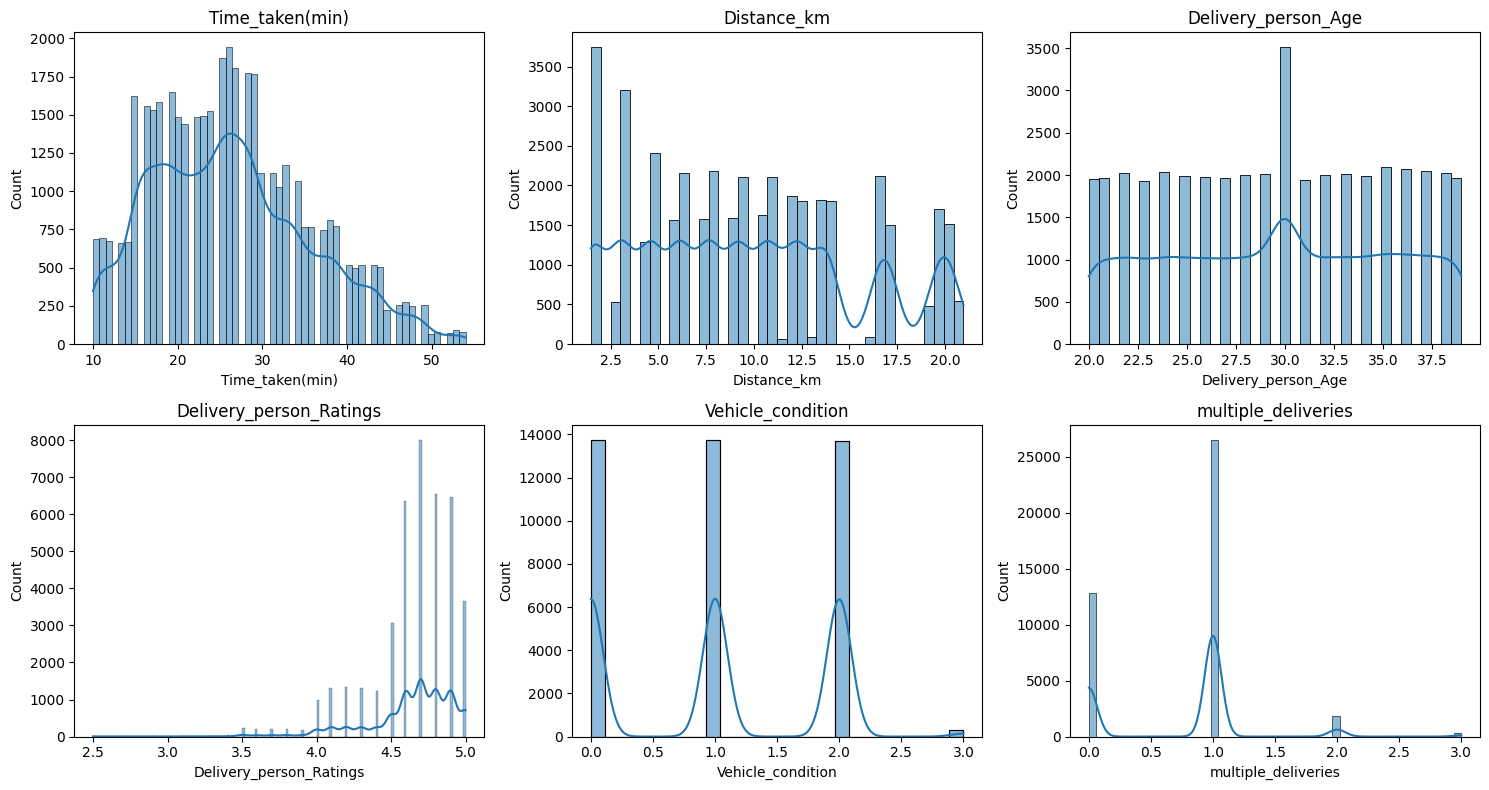

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))





plot_cols = ["Time_taken(min)", "Distance_km", "Delivery_person_Age",





             "Delivery_person_Ratings", "Vehicle_condition", "multiple_deliveries"]





for ax, c in zip(axes.flat, plot_cols):





    sns.histplot(df[c], kde=True, ax=ax)





    ax.set_title(c)





plt.tight_layout()





plt.show()

### 9. EDA — correlation heatmap

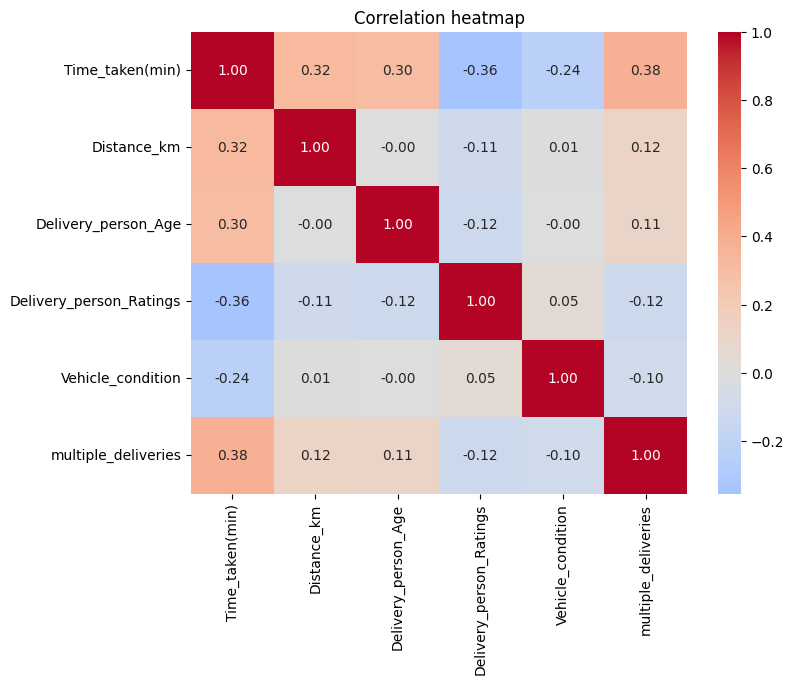

In [ ]:
plt.figure(figsize=(8, 6))





num_predictors = ["Distance_km", "Delivery_person_Age", "Delivery_person_Ratings",





                   "Vehicle_condition", "multiple_deliveries"]





corr = df[["Time_taken(min)"] + num_predictors].corr()





sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")





plt.title("Correlation heatmap")





plt.show()

### 10. Train/test split

In [ ]:
target = "Time_taken(min)"





X = df[num_predictors].copy()





X = pd.concat([





    X,





    pd.get_dummies(df["Road_traffic_density"], prefix="Traffic", drop_first=True),





    pd.get_dummies(df["Weatherconditions"], prefix="Weather", drop_first=True),





    pd.get_dummies(df["Festival"], prefix="Festival", drop_first=True),





    pd.get_dummies(df["City"], prefix="City", drop_first=True),





], axis=1)





y = df[target]











X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





X_train.shape, X_test.shape

((33178, 16), (8295, 16))

### 11. Baseline MLR (full model)

In [ ]:
X_train_c = sm.add_constant(X_train)





baseline_model = sm.OLS(y_train, X_train_c.astype(float)).fit()





print(baseline_model.summary())





baseline_adj_r2 = baseline_model.rsquared_adj





print("Baseline Adj R2:", baseline_adj_r2)

                            OLS Regression Results                            
Dep. Variable:        Time_taken(min)   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     2952.
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:02:27   Log-Likelihood:            -1.0674e+05
No. Observations:               33178   AIC:                         2.135e+05
Df Residuals:                   33161   BIC:                         2.136e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

### 12. Outlier detection — Cook's Distance

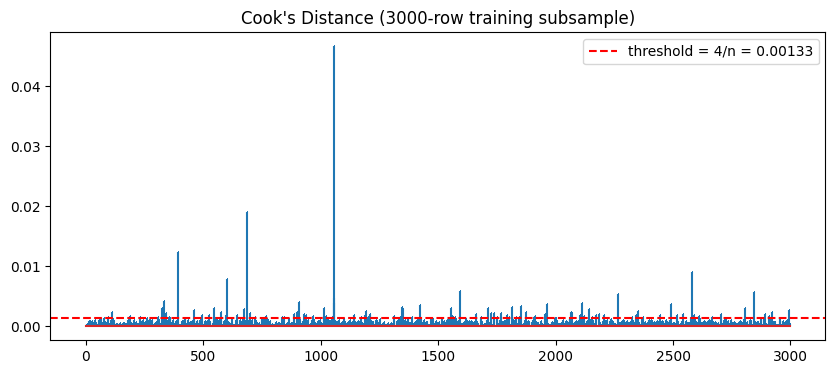

Points flagged by Cook's D: 120


In [ ]:
# on a dataset this large, computing full leverage/influence for every row is





# expensive -- use a random subsample of the training set for outlier diagnostics





sample_idx = X_train.sample(n=3000, random_state=42).index





X_sample = X_train.loc[sample_idx]





y_sample = y_train.loc[sample_idx]





X_sample_c = sm.add_constant(X_sample)





sample_model = sm.OLS(y_sample, X_sample_c.astype(float)).fit()











influence = sample_model.get_influence()





cooks_d = influence.cooks_distance[0]











plt.figure(figsize=(10, 4))





plt.stem(cooks_d, markerfmt=",")





threshold = 4 / len(X_sample)





plt.axhline(threshold, color="red", linestyle="--", label=f"threshold = 4/n = {threshold:.5f}")





plt.title("Cook's Distance (3000-row training subsample)")





plt.legend()





plt.show()











cooks_flagged = np.where(cooks_d > threshold)[0]





print("Points flagged by Cook's D:", len(cooks_flagged))

### 13. Outlier detection — DFFITS

In [ ]:
dffits, dffits_threshold = influence.dffits





dffits_cut = 2 * np.sqrt(X_sample_c.shape[1] / len(X_sample))











dffits_flagged = np.where(np.abs(dffits) > dffits_cut)[0]





print("Points flagged by DFFITS:", len(dffits_flagged))











both_flagged = np.intersect1d(cooks_flagged, dffits_flagged)





print("Flagged by both:", len(both_flagged))

Points flagged by DFFITS: 120
Flagged by both: 120


### 14. Drop influential points and refit

In [ ]:
X_train_clean = X_sample.drop(X_sample.index[both_flagged])





y_train_clean = y_sample.drop(y_sample.index[both_flagged])











X_train_clean_c = sm.add_constant(X_train_clean)





model_no_outliers = sm.OLS(y_train_clean, X_train_clean_c.astype(float)).fit()











print("Adj R2 before (sample):", sample_model.rsquared_adj)





print("Adj R2 after removing influential points:", model_no_outliers.rsquared_adj)

Adj R2 before (sample): 0.5922922489551923
Adj R2 after removing influential points: 0.6358914960588956


### 15. Multicollinearity — VIF table

In [ ]:
# cast to float first -- one-hot dummy columns are boolean by default in





# newer pandas, which breaks the linear algebra inside variance_inflation_factor





X_train_clean = X_train_clean.astype(float)











# VIF must be computed on a design matrix that includes the constant column,





# otherwise predictors that aren't centered near zero (like Age, roughly





# 15-50) get artificially inflated VIF -- this isn't real multicollinearity,





# it's a known statsmodels gotcha





X_vif = sm.add_constant(X_train_clean)





vif_df = pd.DataFrame()





vif_df["feature"] = X_vif.columns





vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]





vif_df = vif_df[vif_df["feature"] != "const"]  # constant's own VIF isn't meaningful, drop it from the view





vif_df.sort_values("VIF", ascending=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
6,Traffic_Jam,3.464463
7,Traffic_Low,3.175214
8,Traffic_Medium,3.064514
9,Weather_Fog,1.831631
10,Weather_Sandstorms,1.759505
13,Weather_Windy,1.753658
11,Weather_Stormy,1.743473
12,Weather_Sunny,1.686765
1,Distance_km,1.245817
5,multiple_deliveries,1.079979


### 16. PCA on the high-VIF feature block

In [ ]:
high_vif_cols = vif_df[(vif_df["VIF"] > 10) & (vif_df["feature"].isin(num_predictors))]["feature"].tolist()





print("Combining into PCA:", high_vif_cols)











if len(high_vif_cols) >= 2:





    pca = PCA(n_components=2, random_state=42)





    pca_train = pca.fit_transform(X_train_clean[high_vif_cols])





    print("Explained variance ratio:", pca.explained_variance_ratio_)





else:





    print("Fewer than 2 features crossed VIF>10 -- PCA skipped, multicollinearity wasn't severe enough to need it")

Combining into PCA: []
Fewer than 2 features crossed VIF>10 -- PCA skipped, multicollinearity wasn't severe enough to need it


### 17. Rebuild feature set (with PCA components if used)

In [ ]:
if len(high_vif_cols) >= 2:





    remaining_cols = [c for c in X_train_clean.columns if c not in high_vif_cols]





    X_train_pca = pd.concat([





        X_train_clean[remaining_cols].reset_index(drop=True),





        pd.DataFrame(pca_train, columns=["PC1", "PC2"])





    ], axis=1)





else:





    X_train_pca = X_train_clean.reset_index(drop=True)











y_train_clean = y_train_clean.reset_index(drop=True)





X_train_pca.head()

,Distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Traffic_Jam,Traffic_Low,Traffic_Medium,Weather_Fog,Weather_Sandstorms,Weather_Stormy,Weather_Sunny,Weather_Windy,Festival_Yes,City_Semi-Urban,City_Urban
0,3.059363,23.0,4.9,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16.635416,24.0,4.7,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.554506,27.0,4.9,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,16.606416,25.0,4.7,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.029525,34.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 18. Backward elimination

In [ ]:
def backward_elimination(X, y, sig_level=0.05):





    X = sm.add_constant(X.astype(float))





    while True:





        model = sm.OLS(y, X).fit()





        pvals = model.pvalues.drop("const")





        worst_p = pvals.max()





        if worst_p > sig_level:





            worst_feature = pvals.idxmax()





            X = X.drop(columns=[worst_feature])





        else:





            break





    return model, X.columns.tolist()











be_model, be_features = backward_elimination(X_train_pca, y_train_clean)





print("Features kept:", be_features)





print("Adj R2 after backward elimination:", be_model.rsquared_adj)

Features kept: ['const', 'Distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'Traffic_Low', 'Traffic_Medium', 'Weather_Sandstorms', 'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy', 'Festival_Yes', 'City_Semi-Urban', 'City_Urban']
Adj R2 after backward elimination: 0.6357277803850883


### 19. Model comparison — AIC / BIC / Mallow's Cp / PRESS

In [ ]:
def press_statistic(model):





    influence = model.get_influence()





    resid = model.resid





    leverage = influence.hat_matrix_diag





    press_resid = resid / (1 - leverage)





    return np.sum(press_resid ** 2)











def mallows_cp(model, full_model):





    n = model.nobs





    p = model.df_model + 1





    mse_full = full_model.mse_resid





    return (model.ssr / mse_full) - (n - 2 * p)











full_model_pca, _ = backward_elimination(X_train_pca, y_train_clean, sig_level=1.0)











comparison = pd.DataFrame({





    "model": ["full_model (all features)", "backward_elimination"],





    "adj_r2": [full_model_pca.rsquared_adj, be_model.rsquared_adj],





    "AIC": [full_model_pca.aic, be_model.aic],





    "BIC": [full_model_pca.bic, be_model.bic],





    "Mallows_Cp": [mallows_cp(full_model_pca, full_model_pca), mallows_cp(be_model, full_model_pca)],





    "PRESS": [press_statistic(full_model_pca), press_statistic(be_model)]





})





comparison

,model,adj_r2,AIC,BIC,Mallows_Cp,PRESS
0,full_model (all features),0.635891,17874.343210,17969.791939,16.000000,83564.855273
1,backward_elimination,0.635728,17873.648337,17957.165975,15.288652,83540.830029


### 20. Final model fit

In [ ]:
final_model = be_model





print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Time_taken(min)   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     387.5
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:02:39   Log-Likelihood:                -8922.8
No. Observations:                2880   AIC:                         1.787e+04
Df Residuals:                    2866   BIC:                         1.796e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


### 21. Assumption checks

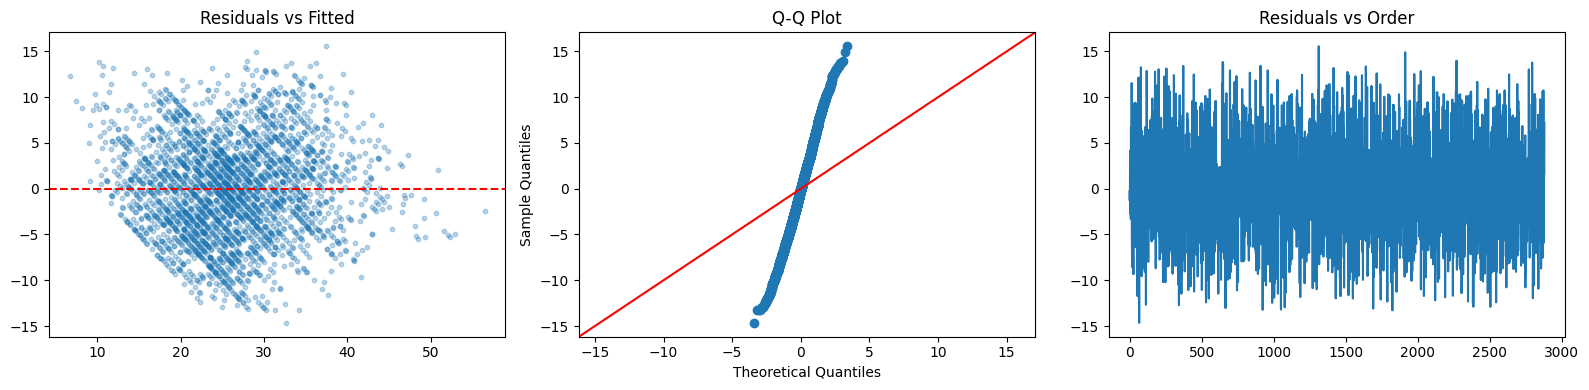

Shapiro-Wilk normality p-value: 8.021523032775475e-07
Durbin-Watson statistic: 1.9649326148160018


In [ ]:
fitted = final_model.fittedvalues





resid = final_model.resid











fig, axes = plt.subplots(1, 3, figsize=(16, 4))











axes[0].scatter(fitted, resid, alpha=0.3, s=10)





axes[0].axhline(0, color="red", linestyle="--")





axes[0].set_title("Residuals vs Fitted")











sm.qqplot(resid, line="45", ax=axes[1])





axes[1].set_title("Q-Q Plot")











axes[2].plot(resid.values)





axes[2].set_title("Residuals vs Order")





plt.tight_layout()





plt.show()











print("Shapiro-Wilk normality p-value:", stats.shapiro(resid.sample(min(len(resid), 5000), random_state=42))[1])





print("Durbin-Watson statistic:", durbin_watson(resid))

### 22. Results summary

In [ ]:
summary_table = pd.DataFrame({





    "stage": ["Baseline (sample, with outliers)", "Final (outliers removed, VIF/PCA, backward elimination)"],





    "Adj_R2": [sample_model.rsquared_adj, final_model.rsquared_adj],





    "n_features": [X_sample.shape[1], len(be_features) - 1]





})





summary_table

,stage,Adj_R2,n_features
0,"Baseline (sample, with outliers)",0.592292,16
1,"Final (outliers removed, VIF/PCA, backward eli...",0.635728,14


### 23. Sanity check on full training data (not just the 3000-row sample)

In [ ]:
# refit the final selected features on the FULL training set to confirm the





# sample-based model selection holds up at full scale





final_features = [c for c in be_features if c != "const" and c in X_train.columns]





X_full_final = sm.add_constant(X_train[final_features].astype(float))





full_scale_model = sm.OLS(y_train, X_full_final).fit()





print("Adj R2 on full training data with selected features:", full_scale_model.rsquared_adj)

Adj R2 on full training data with selected features: 0.5870530879305279


### 24. Save results

In [ ]:
summary_table.to_csv("mlr_results_summary.csv", index=False)





comparison.to_csv("model_comparison_aic_bic_cp_press.csv", index=False)





print("Saved results CSVs")

Saved results CSVs


# Part 2 — ML & DL Model Comparison + Delay Explanation Agent





The MLR pipeline above is the core statistical analysis (outliers,


multicollinearity, model selection, assumptions). This second part compares


it against standard ML/DL regressors on the full cleaned dataset, then builds


a simple agent that explains *why* a specific delivery is predicted to take


as long as it does.

### 25. Prepare features for ML models (full cleaned data, not the outlier-diagnostic sample)

In [ ]:
# MLR needed a small sample for exact Cook's D/DFFITS computation -- ML models


# don't have that constraint, so they train on the full cleaned dataset


X_ml = df[num_predictors].copy()


X_ml = pd.concat([


    X_ml,


    pd.get_dummies(df["Road_traffic_density"], prefix="Traffic", drop_first=True),


    pd.get_dummies(df["Weatherconditions"], prefix="Weather", drop_first=True),


    pd.get_dummies(df["Festival"], prefix="Festival", drop_first=True),


    pd.get_dummies(df["City"], prefix="City", drop_first=True),


], axis=1).astype(float)


y_ml = df["Time_taken(min)"]





print(X_ml.shape)

(41473, 16)


### 26. Train/test split for ML models

In [ ]:
X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)


X_ml_train.shape, X_ml_test.shape

((33178, 16), (8295, 16))

### 27. Metrics helper

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error





results = []





def evaluate(name, model, X_test, y_test, preds):


    r2 = r2_score(y_test, preds)


    mae = mean_absolute_error(y_test, preds)


    rmse = mean_squared_error(y_test, preds) ** 0.5


    results.append({"model": name, "R2": r2, "MAE": mae, "RMSE": rmse})


    print(f"{name}: R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")

### 28. Linear Regression (baseline)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso





lin_reg = LinearRegression()


lin_reg.fit(X_ml_train, y_ml_train)


evaluate("Linear Regression", lin_reg, X_ml_test, y_ml_test, lin_reg.predict(X_ml_test))

Linear Regression: R2=0.586  MAE=4.78  RMSE=5.98


### 29. Ridge & Lasso

In [ ]:
ridge = Ridge(alpha=1.0)


ridge.fit(X_ml_train, y_ml_train)


evaluate("Ridge", ridge, X_ml_test, y_ml_test, ridge.predict(X_ml_test))





lasso = Lasso(alpha=0.1)


lasso.fit(X_ml_train, y_ml_train)


evaluate("Lasso", lasso, X_ml_test, y_ml_test, lasso.predict(X_ml_test))

Ridge: R2=0.586  MAE=4.78  RMSE=5.98
Lasso: R2=0.566  MAE=4.87  RMSE=6.13


### 30. Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor





rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)


rf.fit(X_ml_train, y_ml_train)


evaluate("Random Forest", rf, X_ml_test, y_ml_test, rf.predict(X_ml_test))

Random Forest: R2=0.821  MAE=3.13  RMSE=3.94


### 31. Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor





gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)


gb.fit(X_ml_train, y_ml_train)


evaluate("Gradient Boosting", gb, X_ml_test, y_ml_test, gb.predict(X_ml_test))

Gradient Boosting: R2=0.802  MAE=3.31  RMSE=4.14


### 32. XGBoost Regressor

In [ ]:
!pip install xgboost -q


from xgboost import XGBRegressor





xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)


xgb.fit(X_ml_train, y_ml_train)


evaluate("XGBoost", xgb, X_ml_test, y_ml_test, xgb.predict(X_ml_test))

XGBoost: R2=0.825  MAE=3.10  RMSE=3.89


### 33. CatBoost Regressor

In [ ]:
!pip install catboost -q


from catboost import CatBoostRegressor





catb = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1, random_state=42, verbose=0)


catb.fit(X_ml_train, y_ml_train)


evaluate("CatBoost", catb, X_ml_test, y_ml_test, catb.predict(X_ml_test))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00
CatBoost: R2=0.824  MAE=3.11  RMSE=3.91


### 34. LightGBM Regressor

In [ ]:
!pip install lightgbm -q


from lightgbm import LGBMRegressor





lgbm = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)


lgbm.fit(X_ml_train, y_ml_train)


evaluate("LightGBM", lgbm, X_ml_test, y_ml_test, lgbm.predict(X_ml_test))

LightGBM: R2=0.826  MAE=3.09  RMSE=3.89


### 35. Simple Deep Learning model (Feedforward Neural Network)

In [ ]:
from sklearn.preprocessing import StandardScaler


import tensorflow as tf


from tensorflow import keras





# NN needs scaled inputs, unlike the tree models above


scaler = StandardScaler()


X_dl_train = scaler.fit_transform(X_ml_train)


X_dl_test = scaler.transform(X_ml_test)





dl_model = keras.Sequential([


    keras.layers.Dense(64, activation="relu", input_shape=(X_dl_train.shape[1],)),


    keras.layers.Dense(32, activation="relu"),


    keras.layers.Dense(16, activation="relu"),


    keras.layers.Dense(1)


])


dl_model.compile(optimizer="adam", loss="mse", metrics=["mae"])





history = dl_model.fit(X_dl_train, y_ml_train, validation_split=0.1,


                        epochs=50, batch_size=64, verbose=0)





dl_preds = dl_model.predict(X_dl_test, verbose=0).flatten()


evaluate("Neural Network", dl_model, X_dl_test, y_ml_test, dl_preds)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network: R2=0.809  MAE=3.23  RMSE=4.07


### 36. Model comparison — MLR vs ML vs DL

In [ ]:
# add the classical MLR final model's test-set performance for a fair comparison


mlr_test_features = [c for c in final_features if c in X_ml_test.columns]


mlr_test_c = sm.add_constant(X_ml_test[mlr_test_features].astype(float))


# align columns to the fitted model's expected order


mlr_test_c = mlr_test_c[full_scale_model.params.index]


mlr_preds = full_scale_model.predict(mlr_test_c)


evaluate("Classical MLR (final)", full_scale_model, X_ml_test, y_ml_test, mlr_preds)





results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)


results_df

Classical MLR (final): R2=0.586  MAE=4.78  RMSE=5.98


,model,R2,MAE,RMSE
0,LightGBM,0.825538,3.093031,3.885190
1,XGBoost,0.825025,3.100677,3.890903
2,CatBoost,0.823626,3.112122,3.906427
3,Random Forest,0.820568,3.128013,3.940145
4,Neural Network,0.808652,3.228075,4.068871
5,Gradient Boosting,0.802071,3.308529,4.138247
6,Ridge,0.586128,4.783166,5.984047
7,Linear Regression,0.586117,4.783188,5.984125
8,Classical MLR (final),0.586015,4.784387,5.984864
9,Lasso,0.565589,4.872700,6.130730


### 37. Cross-validation on the top 3 models

In [ ]:
# 5-fold CV on the top 3 models from the comparison table -- checks that the

# R2 scores above aren't a lucky train/test split

from sklearn.model_selection import cross_val_score



cv_models = {"LightGBM": lgbm, "XGBoost": xgb, "CatBoost": catb}

for name, m in cv_models.items():

    scores = cross_val_score(m, X_ml, y_ml, cv=5, scoring="r2", n_jobs=-1)

    print(f"{name}: R2 = {scores.mean():.3f} +/- {scores.std():.3f}  (folds: {np.round(scores, 3)})")

LightGBM: R2 = 0.822 +/- 0.003  (folds: [0.822 0.823 0.824 0.817 0.825])
XGBoost: R2 = 0.822 +/- 0.003  (folds: [0.824 0.823 0.825 0.816 0.824])
CatBoost: R2 = 0.821 +/- 0.003  (folds: [0.821 0.822 0.824 0.815 0.824])


### 38. Optuna hyperparameter tuning (best model)

In [39]:
# Tune whichever model is currently best (LightGBM) -- tuning every model

# would be expensive and the untuned comparison already tells us which

# family of models is worth tuning

!pip install optuna -q

import optuna



def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 500),

        "num_leaves": trial.suggest_int("num_leaves", 15, 127),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "random_state": 42,

        "verbose": -1,

    }

    model = LGBMRegressor(**params)

    scores = cross_val_score(model, X_ml_train, y_ml_train, cv=3, scoring="r2", n_jobs=-1)

    return scores.mean()



study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30, show_progress_bar=True)



print("Best CV R2:", study.best_value)

print("Best params:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 24.8 MB/s eta 0:00:00


[I 2026-08-17 12:06:20,822] A new study created in memory with name: no-name-2dcf4989-6c0d-43d3-9206-0e37ef97ff9b


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-17 12:06:22,104] Trial 0 finished with value: 0.7806479240091436 and parameters: {'n_estimators': 236, 'num_leaves': 121, 'max_depth': 4, 'learning_rate': 0.03892932629473695, 'subsample': 0.6819218107383364, 'colsample_bytree': 0.8763218621533793}. Best is trial 0 with value: 0.7806479240091436.
[I 2026-08-17 12:06:24,588] Trial 1 finished with value: 0.8149272349722931 and parameters: {'n_estimators': 304, 'num_leaves': 56, 'max_depth': 9, 'learning_rate': 0.15735217282388503, 'subsample': 0.9337577052948732, 'colsample_bytree': 0.8632322132430659}. Best is trial 1 with value: 0.8149272349722931.
[I 2026-08-17 12:06:27,182] Trial 2 finished with value: 0.812337574002389 and parameters: {'n_estimators': 202, 'num_leaves': 77, 'max_depth': 9, 'learning_rate': 0.1955517204161995, 'subsample': 0.6921282058113769, 'colsample_bytree': 0.9866707094661902}. Best is trial 1 with value: 0.8149272349722931.
[I 2026-08-17 12:06:27,984] Trial 3 finished with value: 0.7741498772342218 a

### 39. Refit tuned model and compare

In [40]:
tuned_lgbm = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)

tuned_lgbm.fit(X_ml_train, y_ml_train)

evaluate("LightGBM (Optuna-tuned)", tuned_lgbm, X_ml_test, y_ml_test, tuned_lgbm.predict(X_ml_test))



results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)

results_df

LightGBM (Optuna-tuned): R2=0.829  MAE=3.06  RMSE=3.84


,model,R2,MAE,RMSE
0,LightGBM (Optuna-tuned),0.829259,3.064774,3.843531
1,LightGBM,0.825538,3.093031,3.885190
2,XGBoost,0.825025,3.100677,3.890903
3,CatBoost,0.823626,3.112122,3.906427
4,Random Forest,0.820568,3.128013,3.940145
5,Neural Network,0.808652,3.228075,4.068871
6,Gradient Boosting,0.802071,3.308529,4.138247
7,Ridge,0.586128,4.783166,5.984047
8,Linear Regression,0.586117,4.783188,5.984125
9,Classical MLR (final),0.586015,4.784387,5.984864


### 40. Set the final model (tuned, if it won)

In [41]:
best_model_name = results_df.iloc[0]["model"]

print("Winner:", best_model_name)



# use the tuned model if it's the winner, otherwise fall back to the

# untuned model lookup from the original comparison

if best_model_name == "LightGBM (Optuna-tuned)":

    best_model = tuned_lgbm

else:

    model_lookup = {"XGBoost": xgb, "CatBoost": catb, "LightGBM": lgbm,

                     "Random Forest": rf, "Gradient Boosting": gb}

    best_model = model_lookup.get(best_model_name, tuned_lgbm)



print("Using:", best_model_name)

Winner: LightGBM (Optuna-tuned)
Using: LightGBM (Optuna-tuned)


### 41. SHAP explainability on the best model

Explaining: LightGBM (Optuna-tuned)


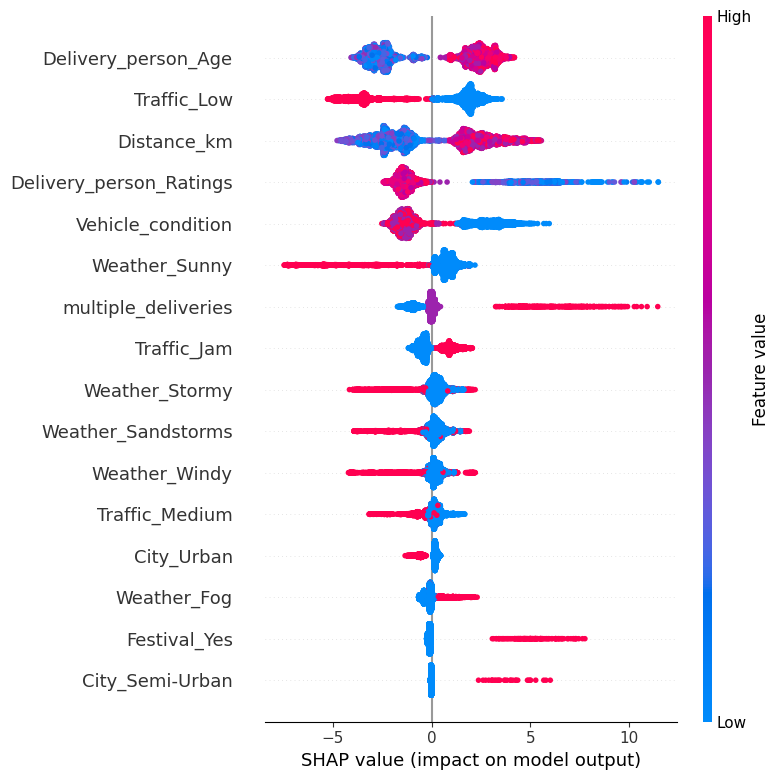

In [42]:
!pip install shap -q

import shap



# best_model and best_model_name were already set in the previous cell

# (using the tuned model if it won)

print("Explaining:", best_model_name)



explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_ml_test)



shap.summary_plot(shap_values, X_ml_test, show=True)

### 42. Delay Explanation Agent

In [ ]:
# Rule-based explanation from SHAP values -- always works, no external model needed.


# Takes one test-set order and explains which features pushed the predicted


# time up or down the most, in plain English.





def explain_delivery(row_index, top_n=3):


    row = X_ml_test.iloc[[row_index]]


    pred = best_model.predict(row)[0]


    row_shap = explainer.shap_values(row)[0]





    contributions = pd.Series(row_shap, index=row.columns).sort_values(key=abs, ascending=False)


    top_features = contributions.head(top_n)





    lines = [f"Predicted delivery time: {pred:.1f} minutes."]


    for feat, val in top_features.items():


        direction = "increased" if val > 0 else "decreased"


        lines.append(f" - {feat} {direction} the estimate by {abs(val):.1f} min (value: {row[feat].values[0]:.2f})")


    return "\n".join(lines)





print(explain_delivery(0))

### 43. Try the agent on a few sample orders

In [ ]:
for i in [0, 5, 20]:


    print(f"--- Order {i} ---")


    print(explain_delivery(i))


    print()

### 44. Optional — rephrase the explanation naturally with a small local LLM

In [ ]:
# Same model family as the Financial Research Assistant project (Qwen2.5),


# used here just to turn the rule-based explanation into a natural sentence.


# This step is optional and needs a GPU runtime -- skip it if running on CPU.





!pip install transformers accelerate -q


from transformers import pipeline





llm = pipeline("text-generation", model="Qwen/Qwen2.5-3B-Instruct",


               device_map="auto", torch_dtype="auto")





def explain_delivery_natural(row_index, top_n=3):


    raw_explanation = explain_delivery(row_index, top_n)


    prompt = (


        "Rewrite this delivery time explanation as one short, natural sentence "


        "for a customer. Keep it factual, don't invent numbers not given.\n\n"


        + raw_explanation


    )


    messages = [{"role": "user", "content": prompt}]


    output = llm(messages, max_new_tokens=80, do_sample=False)


    return output[0]["generated_text"][-1]["content"]





print(explain_delivery_natural(0))

In [46]:
import joblib





# save whichever tree model was best -- the Streamlit app loads this file directly


joblib.dump(best_model, "best_model.pkl")


joblib.dump(list(X_ml_train.columns), "feature_columns.pkl")


print("Saved best_model.pkl and feature_columns.pkl -- download these two files")


print("(Colab: use the file browser on the left, right-click each file -> Download)")

Saved best_model.pkl and feature_columns.pkl -- download these two files
(Colab: use the file browser on the left, right-click each file -> Download)


# Part 3 — Production-Style Pipeline (following the reference Swiggy delivery-time project workflow)

Part 2 compared models on hand-built one-hot features. This part follows a
more production-style approach, based on the structure of a public reference
project for this same problem: richer time-based features, a proper
scikit-learn `ColumnTransformer` pipeline (instead of manual `get_dummies`),
a power-transformed target, Optuna-based model *selection* across several
model families (not just tuning one), focused tuning on the top 2, and a
final Stacking Regressor. No MLflow/DagsHub tracking here — kept
self-contained for Colab.

### 45. Additional feature engineering — pickup time, distance bucket, weekend, time of day

In [ ]:
# gap between order placed and order picked up -- a real operational signal
# not used anywhere yet
df["Time_Orderd_parsed"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors="coerce")
df["Time_Order_picked_parsed"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M:%S", errors="coerce")
pickup_gap = (df["Time_Order_picked_parsed"] - df["Time_Orderd_parsed"]).dt.total_seconds() / 60
# pickup time can appear to be "before" order time when it crosses midnight -- fix that
pickup_gap[pickup_gap < 0] += 24 * 60
df["pickup_time_minutes"] = pickup_gap
df["pickup_time_minutes"] = df["pickup_time_minutes"].fillna(df["pickup_time_minutes"].median())

# distance bucketed into an ordinal category (short/medium/long/very_long)
df["distance_type"] = pd.cut(df["Distance_km"], bins=[0, 5, 10, 15, 100],
                               labels=["short", "medium", "long", "very_long"])

# day of week from Order_Date
df["Order_Date_parsed"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y", errors="coerce")
df["is_weekend"] = df["Order_Date_parsed"].dt.dayofweek.isin([5, 6]).map({True: "yes", False: "no"})

# time-of-day bucket from order time
def time_of_day(t):
    if pd.isna(t):
        return "unknown"
    h = t.hour
    if 5 <= h < 12:
        return "morning"
    elif 12 <= h < 17:
        return "afternoon"
    elif 17 <= h < 21:
        return "evening"
    return "night"

df["order_time_of_day"] = df["Time_Orderd_parsed"].apply(time_of_day)

df[["pickup_time_minutes", "distance_type", "is_weekend", "order_time_of_day"]].head()

### 46. Train/test split (with new features)

In [ ]:
feature_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "pickup_time_minutes", "Distance_km",
                 "Weatherconditions", "Type_of_order", "Type_of_vehicle", "Festival", "City",
                 "is_weekend", "order_time_of_day", "Road_traffic_density", "distance_type"]

X_v3 = df[feature_cols].copy()
y_v3 = df["Time_taken(min)"]

X_v3_train, X_v3_test, y_v3_train, y_v3_test = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)
X_v3_train.shape, X_v3_test.shape

### 47. Preprocessing pipeline (ColumnTransformer: scale + one-hot + ordinal)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, PowerTransformer
from sklearn.compose import TransformedTargetRegressor

num_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "pickup_time_minutes", "Distance_km"]
nominal_cols = ["Weatherconditions", "Type_of_order", "Type_of_vehicle", "Festival", "City",
                "is_weekend", "order_time_of_day"]
ordinal_cols = ["Road_traffic_density", "distance_type"]

# explicit category order matters for ordinal encoding -- low < medium < high < jam
# reflects real increasing severity, which a plain one-hot would throw away
traffic_order = ["Low", "Medium", "High", "Jam"]
distance_type_order = ["short", "medium", "long", "very_long"]

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order, distance_type_order],
                                        handle_unknown="use_encoded_value", unknown_value=-1), ordinal_cols),
])

processing_pipeline = Pipeline(steps=[("preprocess", preprocessor)])

X_v3_train_trans = processing_pipeline.fit_transform(X_v3_train)
X_v3_test_trans = processing_pipeline.transform(X_v3_test)

print(X_v3_train_trans.shape)

### 48. Target transformation (PowerTransformer)

In [50]:
# delivery time is right-skewed (see Part 1 EDA) -- a power transform on the
# target can help models that are sensitive to that, and TransformedTargetRegressor
# handles the inverse-transform automatically at prediction time
pt = PowerTransformer()
y_v3_train_pt = pt.fit_transform(y_v3_train.values.reshape(-1, 1)).ravel()
y_v3_test_pt = pt.transform(y_v3_test.values.reshape(-1, 1)).ravel()

### 49. Optuna model selection (searches across model families, not just one)

In [51]:
# unlike Part 2's fixed model list, this single search lets Optuna pick BOTH
# the model family and its hyperparameters together
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

def selection_objective(trial):
    model_name = trial.suggest_categorical("model", ["RF", "KNN", "SVM", "GB", "XGB", "LGBM"])

    if model_name == "RF":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("rf_n_estimators", 50, 300),
            max_depth=trial.suggest_int("rf_max_depth", 3, 20),
            min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
            random_state=42, n_jobs=-1)
    elif model_name == "KNN":
        model = KNeighborsRegressor(n_neighbors=trial.suggest_int("knn_n_neighbors", 3, 30))
    elif model_name == "SVM":
        model = SVR(C=trial.suggest_float("svm_c", 0.1, 10, log=True),
                    kernel=trial.suggest_categorical("svm_kernel", ["linear", "rbf"]))
    elif model_name == "GB":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("gb_n_estimators", 50, 300),
            max_depth=trial.suggest_int("gb_max_depth", 2, 8),
            learning_rate=trial.suggest_float("gb_lr", 0.01, 0.3, log=True),
            random_state=42)
    elif model_name == "XGB":
        model = XGBRegressor(
            n_estimators=trial.suggest_int("xgb_n_estimators", 50, 300),
            max_depth=trial.suggest_int("xgb_max_depth", 2, 10),
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.3, log=True),
            random_state=42, n_jobs=-1)
    else:  # LGBM
        model = LGBMRegressor(
            n_estimators=trial.suggest_int("lgbm_n_estimators", 50, 300),
            max_depth=trial.suggest_int("lgbm_max_depth", 2, 15),
            learning_rate=trial.suggest_float("lgbm_lr", 0.01, 0.3, log=True),
            random_state=42, verbose=-1)

    scores = cross_val_score(model, X_v3_train_trans, y_v3_train_pt, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -scores.mean()  # minimize MAE

selection_study = optuna.create_study(direction="minimize", study_name="model_selection")
selection_study.optimize(selection_objective, n_trials=30, show_progress_bar=True)

print("Best model family:", selection_study.best_params["model"])
print("Best CV MAE (transformed target):", selection_study.best_value)

[I 2026-08-17 12:12:08,468] A new study created in memory with name: model_selection


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-17 12:12:10,790] Trial 0 finished with value: 0.4064407016915306 and parameters: {'model': 'LGBM', 'lgbm_n_estimators': 227, 'lgbm_max_depth': 15, 'lgbm_lr': 0.027219333657569594}. Best is trial 0 with value: 0.4064407016915306.
[I 2026-08-17 12:12:11,826] Trial 1 finished with value: 0.48931109466619965 and parameters: {'model': 'XGB', 'xgb_n_estimators': 126, 'xgb_max_depth': 3, 'xgb_lr': 0.02592545543215595}. Best is trial 0 with value: 0.4064407016915306.
[I 2026-08-17 12:12:14,066] Trial 2 finished with value: 0.4268743369179435 and parameters: {'model': 'LGBM', 'lgbm_n_estimators': 121, 'lgbm_max_depth': 6, 'lgbm_lr': 0.027797519953084923}. Best is trial 0 with value: 0.4064407016915306.
[I 2026-08-17 12:12:24,525] Trial 3 finished with value: 0.5345815406341232 and parameters: {'model': 'KNN', 'knn_n_neighbors': 21}. Best is trial 0 with value: 0.4064407016915306.
[I 2026-08-17 12:13:05,377] Trial 4 finished with value: 0.40447160128283927 and parameters: {'model': 'R

### 50. Focused tuning — Random Forest (deeper search)

In [52]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_v3_train_trans, y_v3_train_pt, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -scores.mean()

rf_study = optuna.create_study(direction="minimize", study_name="rf_tuning")
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)

best_rf_params = rf_study.best_params
print("Best RF params:", best_rf_params)
print("Best RF CV MAE:", rf_study.best_value)

[I 2026-08-17 12:27:05,915] A new study created in memory with name: rf_tuning


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-17 12:27:11,396] Trial 0 finished with value: 0.45257090815490947 and parameters: {'n_estimators': 249, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.5325766361366759}. Best is trial 0 with value: 0.45257090815490947.
[I 2026-08-17 12:27:28,709] Trial 1 finished with value: 0.41634819905600146 and parameters: {'n_estimators': 442, 'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.6011455993452339}. Best is trial 1 with value: 0.41634819905600146.
[I 2026-08-17 12:27:33,568] Trial 2 finished with value: 0.42493177937382054 and parameters: {'n_estimators': 170, 'max_depth': 29, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_samples': 0.5336424599542435}. Best is trial 1 with value: 0.41634819905600146.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-08-17 12:27:55,944] Trial 3 finished with value: 0.4212928611534106 and parameters: {'n_estimators': 429, 'max_depth': 27, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.8527488626618145}. Best is trial 1 with value: 0.41634819905600146.
[I 2026-08-17 12:28:28,661] Trial 4 finished with value: 0.406050315849261 and parameters: {'n_estimators': 244, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': None, 'max_samples': 0.9919488896128366}. Best is trial 4 with value: 0.406050315849261.
[I 2026-08-17 12:28:41,156] Trial 5 finished with value: 0.4317790892944247 and parameters: {'n_estimators': 362, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'max_samples': 0.7058049762622938}. Best is trial 4 with value: 0.406050315849261.
[I 2026-08-17 12:28:56,477] Trial 6 finished with value: 0.40683381790500145 and parameters: {'n_estimators': 135, 'max_depth': 27, 'min_samples_

### 51. Focused tuning — LightGBM (deeper search)

In [53]:
def lgbm_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
    }
    model = LGBMRegressor(**params, random_state=42, verbose=-1)
    scores = cross_val_score(model, X_v3_train_trans, y_v3_train_pt, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -scores.mean()

lgbm_study = optuna.create_study(direction="minimize", study_name="lgbm_tuning")
lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=True)

best_lgbm_params = lgbm_study.best_params
print("Best LGBM params:", best_lgbm_params)
print("Best LGBM CV MAE:", lgbm_study.best_value)

[I 2026-08-17 12:39:07,592] A new study created in memory with name: lgbm_tuning


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-17 12:39:14,321] Trial 0 finished with value: 0.5087354348157337 and parameters: {'n_estimators': 71, 'max_depth': 4, 'learning_rate': 0.0237667188921117, 'subsample': 0.8747588790529077, 'num_leaves': 40}. Best is trial 0 with value: 0.5087354348157337.
[I 2026-08-17 12:39:18,512] Trial 1 finished with value: 0.4104638870888359 and parameters: {'n_estimators': 250, 'max_depth': 30, 'learning_rate': 0.02626415650490704, 'subsample': 0.7022449132003721, 'num_leaves': 23}. Best is trial 1 with value: 0.4104638870888359.
[I 2026-08-17 12:39:19,311] Trial 2 finished with value: 0.40767973845464006 and parameters: {'n_estimators': 55, 'max_depth': 20, 'learning_rate': 0.22852380206318132, 'subsample': 0.5432267571776598, 'num_leaves': 104}. Best is trial 2 with value: 0.40767973845464006.
[I 2026-08-17 12:39:21,700] Trial 3 finished with value: 0.4223210516807622 and parameters: {'n_estimators': 237, 'max_depth': 29, 'learning_rate': 0.1856317965081313, 'subsample': 0.81245660915

### 52. Stacking Regressor (RF + LightGBM, Linear Regression meta-learner)

In [54]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

best_rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
best_lgbm = LGBMRegressor(**best_lgbm_params, random_state=42, verbose=-1)

stacking_reg = StackingRegressor(
    estimators=[("rf", best_rf), ("lgbm", best_lgbm)],
    final_estimator=LinearRegression(),
    cv=5, n_jobs=-1)

# wrap in TransformedTargetRegressor so predict() automatically inverse-transforms
# back to real minutes -- callers never need to know about the PowerTransformer
final_model_v3 = TransformedTargetRegressor(regressor=stacking_reg, transformer=pt)
final_model_v3.fit(X_v3_train_trans, y_v3_train)

print("Fitted.")

Fitted.


### 53. Evaluate the final stacked model

In [55]:
y_v3_train_pred = final_model_v3.predict(X_v3_train_trans)
y_v3_test_pred = final_model_v3.predict(X_v3_test_trans)

train_mae = mean_absolute_error(y_v3_train, y_v3_train_pred)
test_mae = mean_absolute_error(y_v3_test, y_v3_test_pred)
train_r2 = r2_score(y_v3_train, y_v3_train_pred)
test_r2 = r2_score(y_v3_test, y_v3_test_pred)

print(f"Train: R2={train_r2:.3f}  MAE={train_mae:.2f}")
print(f"Test:  R2={test_r2:.3f}  MAE={test_mae:.2f}")

results.append({"model": "Stacking (RF+LGBM, Part 3 pipeline)", "R2": test_r2, "MAE": test_mae,
                 "RMSE": mean_squared_error(y_v3_test, y_v3_test_pred) ** 0.5})
pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train: R2=0.790  MAE=3.39
Test:  R2=0.761  MAE=3.58


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,R2,MAE,RMSE
0,LightGBM (Optuna-tuned),0.829259,3.064774,3.843531
1,LightGBM,0.825538,3.093031,3.885190
2,XGBoost,0.825025,3.100677,3.890903
3,CatBoost,0.823626,3.112122,3.906427
4,Random Forest,0.820568,3.128013,3.940145
5,Neural Network,0.808652,3.228075,4.068871
6,Gradient Boosting,0.802071,3.308529,4.138247
7,"Stacking (RF+LGBM, Part 3 pipeline)",0.760881,3.583235,4.548504
8,Ridge,0.586128,4.783166,5.984047
9,Linear Regression,0.586117,4.783188,5.984125


### 54. Save the full pipeline for deployment

In [56]:
import joblib

# save the preprocessing pipeline and final model together -- the Streamlit
# app only needs to call processing_pipeline.transform() then final_model_v3.predict()
joblib.dump(processing_pipeline, "processing_pipeline.pkl")
joblib.dump(final_model_v3, "final_model_v3.pkl")
print("Saved processing_pipeline.pkl and final_model_v3.pkl")

Saved processing_pipeline.pkl and final_model_v3.pkl
